## Main Calculation
Checkpoint results are stored in `outputs/logs/` at regular intervals, `save_interval`.


In [1]:
import sys
sys.path.append('../src')

In [2]:
import jax
import jax.numpy as jnp
import os
import numpy as np
import matplotlib.pyplot as plt
from pinn.train import create_train_state, train_step
from pinn.cryoet_io import load_mrc_data
import pickle
from flax.training import checkpoints
from pinn.utils import initial_loss
from tqdm.notebook import trange

GRID_SIZE = 64
NUM_CHECKPOINTS_TO_KEEP = 1000  # Checkpoint retention count (older ones get removed)

# Set loss function weights
lambda_1 = 1000000      # Weight for boundary loss
lambda_2 = 50           # Weight for physics loss
shape = "bud_04"
sdf_pretrain="sphere"   # sphere or plane

# Initialize JAX random key
key = jax.random.PRNGKey(0)
# 
# Set directory for initial condition
# ckpt_dir = os.path.abspath(f"../outputs/logs/test_phase/snwitch2-2/30000/default")
# ckpt_dir = os.path.abspath(f"../outputs/logs/biconcave/round_1/lambda_5000000_1e-05/checkpoint_30000/")
# init_ckpt = checkpoints.restore_checkpoint(ckpt_dir=ckpt_dir, target=None)

# Create train state
# state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, learning_rate=1e-3, init_ckpt=init_ckpt)
state, model = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2, sdf_pretrain=sdf_pretrain, learning_rate=1e-3)
print(f"Using lambda_1: {state.lambda_1}, lambda_2: {state.lambda_2}")

#### LOAD MRC DATA #####
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
# missing_ratio=0.998
# mrc_file_path = f"../data/synthetic/biconcave_fragment_{str(missing_ratio).replace('.', '')}.mrc"
# flip_ratio=0.2
# mrc_file_path = f"../data/synthetic/biconcave_noisy_{str(flip_ratio).replace('.', '')}.mrc"
# sigma_blur = 5
# mrc_file_path = f"../data/synthetic/biconcave_blur_{str(sigma_blur).replace('.', '')}.mrc"
# num_patch=10
# rad_patch=25
# mrc_file_path = f"../data/synthetic/biconcave_patch_{num_patch}_{rad_patch}.mrc"

flip_ratio=0.175
# wedge_axis='y'
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"

cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)
print("MRC data loaded successfully! Shape:", cryoET_data.shape)
print("Cryo-ET Data Shape:", cryoET_data.shape)
print("Cryo-ET Data Min:", cryoET_data.min())
print("Cryo-ET Data Max:", cryoET_data.max())
print("Cryo-ET Unique Values:", jnp.unique(cryoET_data))

# Training Data
num_collocation = 10000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1)) # Sampled from [-1, 1]^3


# Training loop
num_steps = 10000
# num_steps = 1000
save_interval = 100


# # temporary 
# binary_mask = jnp.where(cryoET_data > 0.8, 1, 0)
# membrane_indices = jnp.where(binary_mask.ravel() == 1)[0]

checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")

checkpoints.save_checkpoint(
    ckpt_dir=checkpoint_dir,
    target={"state": state, "loss": initial_loss(state, x_train, cryoET_data)},
    # target={"state": state, "loss": initial_loss(state, x_train, cryoET_data, membrane_indices)},
    step=0,
    overwrite=False,
    keep=NUM_CHECKPOINTS_TO_KEEP,
)
loss_history = []


# for step in range(num_steps):
for step in trange(num_steps):
    state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data)
    # state, loss_val, loss_data_val, loss_physics_val = train_step(state, x_train, cryoET_data, membrane_indices)

    loss_history.append({
        "step": step + 1,
        "total_loss": loss_val,
        "data_loss": loss_data_val,
        "physics_loss": loss_physics_val
    })

    if (step+1) % save_interval == 0:

        loss_history = {key: np.array([entry[key] for entry in loss_history]) for key in loss_history[0].keys()}
        
        checkpoints.save_checkpoint(
            ckpt_dir = checkpoint_dir,
            target={"state": state, "loss": loss_history},
            step=step+1, 
            overwrite=False, 
            keep=NUM_CHECKPOINTS_TO_KEEP,
        )
        print(f"Checkpoint saved at step {step+1}")

        loss_history = []


KeyboardInterrupt: 

### Analysis

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/lambda_1000000_50


/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


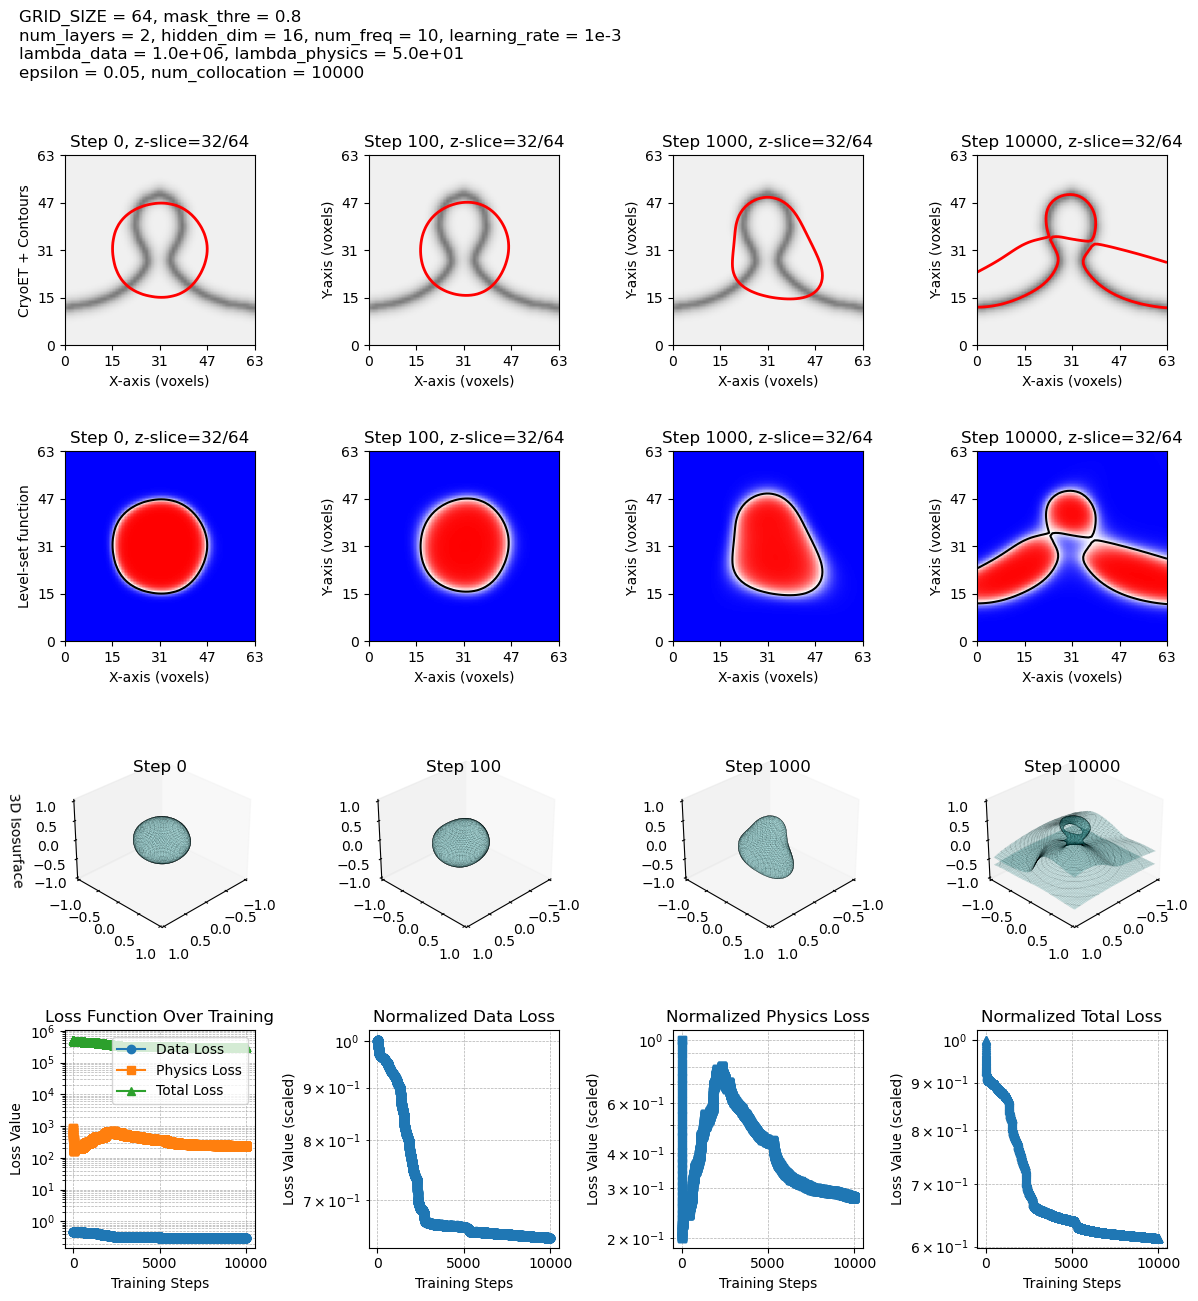

In [3]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 1000000
# lambda_2 = 100
num_collocation = 10000
# num_collocation = 1000
num_layers = 2
# shape = "bud"


# steps_to_visualize = [0, 200, 600, 1000]
# steps_series = list(range(0, 1001, 100))
steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
mrc_file_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

/gscratch/matsulab/envs/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


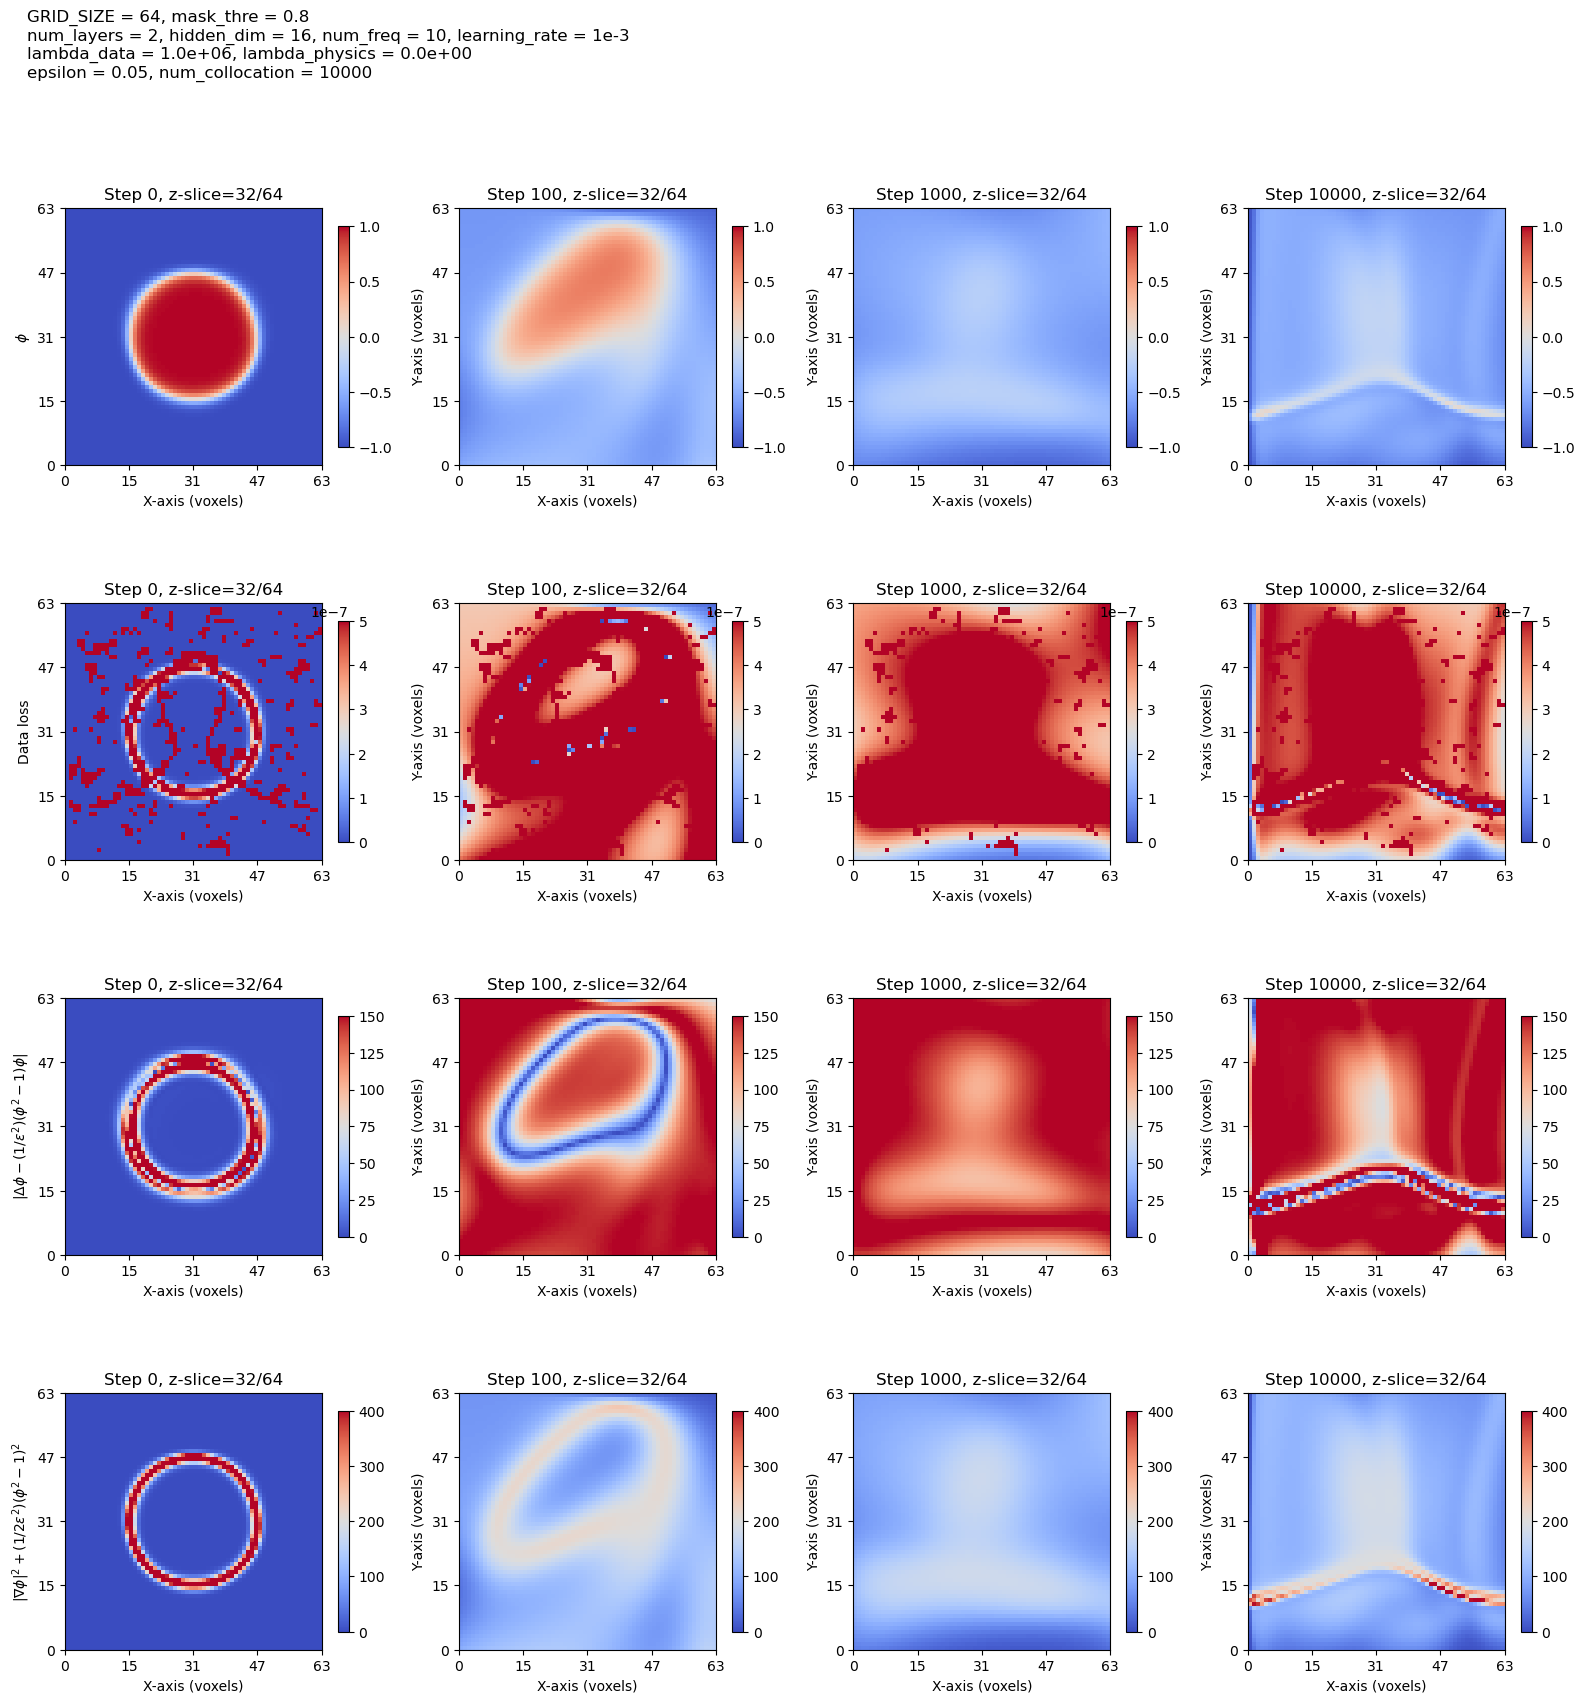

In [22]:
## make one combined physics analysis image

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_physics_loss,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
# lambda_1 = 5000000
# lambda_2 = 1
num_collocation = 10000
num_layers = 2
epsilon = 0.05
# shape = "multi"

# steps_to_visualize = [0, 200, 600, 1000]
# steps_to_visualize = [0, 2000, 6000, 10000]
# steps_to_visualize = [0, 1000, 6000, 10000]
steps_to_visualize = [0, 100, 1000, 10000]
# steps_to_visualize = [0, 10000, 20000, 30000]
# steps_to_visualize = [0, 30000, 60000, 90000]

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/lambda_{lambda_1}_{lambda_2}")
checkpoint_data = {}
for step in steps_to_visualize:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)


# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(4*4, 4*4))


# Row 1: Phi
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="phi",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=-1, vmax=1)
    # visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=32, axis="z", colorbar = True)
    if i == 0:
        ax.set_ylabel(r"$\phi$")

# Row 2: data loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="data",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=5e-7, cryoET_data=cryoET_data)
    if i == 0:
        ax.set_ylabel(r"Data loss")

# Row 3: physics loss
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="residual",
                           grid_size=GRID_SIZE, slice_index=32, axis="z", vmin=0, vmax=150)

    if i == 0:
        ax.set_ylabel(r"$|\Delta \phi - (1/\epsilon^2)(\phi^2 - 1)\phi|$")

# Row 4: tension energy
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 12 + i + 1)
    visualize_physics_loss(ax, epsilon=epsilon, step=step,
                           checkpoint=checkpoint_data[step], component="tension",
                           grid_size=GRID_SIZE, slice_index=int(GRID_SIZE/2), axis="z", vmin=0, vmax=400)
    if i == 0:
        ax.set_ylabel(r"$|\nabla \phi|^2 + (1/2\epsilon^2) (\phi^2 -1)^2$")
        # ax.set_ylabel(r"$|\nabla\phi|^2$")


info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = {epsilon}, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/physics.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# Make a movie

import matplotlib.pyplot as plt
import os
from pinn.plot import plot_3d_isosurface
from flax.training import checkpoints
import imageio
import re

steps_to_visualize = list(range(0, 30001, 1000))
log_dir = os.path.abspath(f"../outputs/logs/biconcave/lambda_{lambda_1}_{lambda_2}/")
frame_dir = os.path.join(log_dir, f"frames")

def save_isosurface_frame(step, checkpoint, save_dir="frames", grid_size=64):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint, grid_size)
    
    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    # Match files like frame_XXXX.png and extract the numeric part
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for _, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)

for step in steps_to_visualize:
    ckpt_path = os.path.join(log_dir, f"checkpoint_{step}")
    ckpt_data = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)
    print(f"saving step {step}")
    save_isosurface_frame(step, ckpt_data, save_dir=frame_dir)

output=os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)

/gscratch/matsulab/env/pinn-env/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1175: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


saving step 0
saving step 1000
saving step 2000
saving step 3000
saving step 4000
saving step 5000
saving step 6000
saving step 7000
saving step 8000
saving step 9000
saving step 10000
saving step 11000
saving step 12000
saving step 13000
saving step 14000
saving step 15000
saving step 16000
saving step 17000
saving step 18000
saving step 19000
saving step 20000
saving step 21000
saving step 22000
saving step 23000
saving step 24000
saving step 25000
saving step 26000
saving step 27000
saving step 28000
saving step 29000
saving step 30000


/tmp/ipykernel_47702/3018667548.py:40: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
/gscratch/matsulab/env/pinn-env/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


In [ ]:
import sys
sys.path.append('../src')

%run routine.py

Input file: ../data/synthetic/flip_noise/multi_f015.mrc
Resizing MRC data from (128, 128, 128) to (64, 64, 64)
MRC data loaded successfully! Shape: (64, 64, 64)
Cryo-ET Data Shape: (64, 64, 64)
Cryo-ET Data Min: 0.13997021
Cryo-ET Data Max: 0.98760295
Cryo-ET Unique Values: [0.13997021 0.14019899 0.1455879  ... 0.9793758  0.98038423 0.98760295]
Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 0


  0%|          | 0/10000 [00:00<?, ?it/s]

Pretraining the network using SDF...
Using lambda_1: 1000000, lambda_2: 10


  0%|          | 0/10000 [00:00<?, ?it/s]